In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

In [2]:
data = load_breast_cancer()
type(data)

sklearn.utils._bunch.Bunch

In [3]:
dir(data)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [4]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [5]:
data.data.shape

(569, 30)

In [6]:
data.target.shape

(569,)

In [7]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [8]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [9]:
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [10]:
import numpy as np
np.bincount(data.target)

array([212, 357])

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size = 0.2, random_state = 42,stratify=data.target
)

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [13]:
np.bincount(y_train), np.bincount(y_test)

(array([170, 285]), array([42, 72]))

In [14]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_score = dummy.score(X_test, y_test)
dummy_score

0.631578947368421

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


cancer_model = LogisticRegression(random_state=42)
cancer_model.fit(X_train_scaled, y_train)
cancer_model_score = cancer_model.score(X_test_scaled, y_test)
cancer_model_score

0.9824561403508771

In [16]:
from sklearn.metrics import confusion_matrix

y_pred = cancer_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
cm

array([[41,  1],
       [ 1, 71]])

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=data.target_names))


              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [18]:
y_probs = cancer_model.predict_proba(X_test_scaled)
y_probs[:5]

array([[9.99999941e-01, 5.88824186e-08],
       [1.13351672e-05, 9.99988665e-01],
       [9.93589175e-01, 6.41082462e-03],
       [4.66491463e-01, 5.33508537e-01],
       [9.99999999e-01, 6.52500097e-10]])

In [19]:
custom_threshold = 0.3
y_pred_custom = (y_probs[:, 1] >= ( 1- custom_threshold)).astype(int)
np.bincount(y_pred_custom)

array([46, 68])

In [20]:
cm_custom = confusion_matrix(y_test, y_pred_custom)
cm_custom

array([[41,  1],
       [ 5, 67]])

In [21]:
custom_threshold = 0.1
y_pred_low = (y_probs[:, 1] >= (1- custom_threshold)).astype(int)
cm_low = confusion_matrix(y_test, y_pred_low)
cm_low

array([[41,  1],
       [11, 61]])

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

In [23]:
print(classification_report(y_test, rf_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [24]:
cm_rf = confusion_matrix(y_test, rf_pred)
cm_rf

array([[39,  3],
       [ 2, 70]])

In [25]:
from sklearn.svm import SVC

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

C:\ML_Projects\breast-cancer-classifier\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [26]:
print(classification_report(y_test, svm_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [27]:
cm_svm = confusion_matrix(y_test, svm_pred)
cm_svm

array([[41,  1],
       [ 1, 71]])

In [28]:
mismatches_lr = X_test[y_test != y_pred]
mismatches_svm = X_test[y_test != svm_pred]

In [29]:
import numpy as np
np.array_equal(mismatches_lr, mismatches_svm)

True

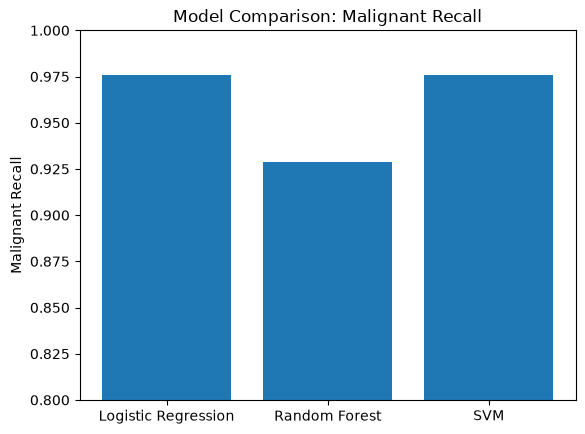

In [30]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest', 'SVM']
recalls = [0.976, 0.929, 0.976]

plt.bar(models, recalls)
plt.ylabel('Malignant Recall')
plt.title('Model Comparison: Malignant Recall')
plt.ylim(0.8, 1.0)
plt.show()

In [31]:
report_lr = classification_report(y_test, y_pred, target_names=data.target_names, output_dict=True)
report_rf = classification_report(y_test, rf_pred, target_names=data.target_names, output_dict=True)
report_svm = classification_report(y_test, svm_pred, target_names=data.target_names, output_dict=True)

In [32]:
recalls = [
    report_lr['malignant']['recall'],
    report_rf['malignant']['recall'],
    report_svm['malignant']['recall']
]
recalls

[0.9761904761904762, 0.9285714285714286, 0.9761904761904762]

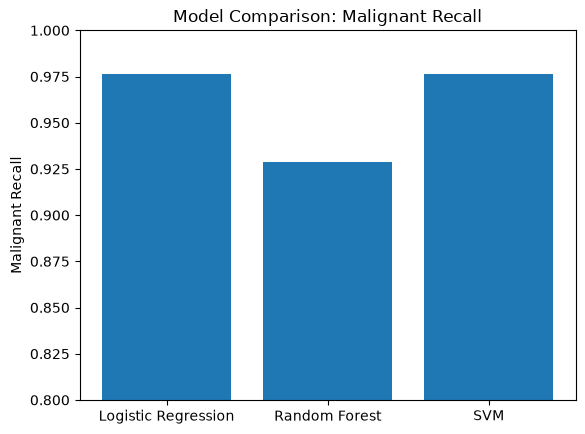

In [33]:
plt.bar(models, recalls)
plt.ylabel('Malignant Recall')
plt.title('Model Comparison: Malignant Recall')
plt.ylim(0.8, 1.0)
plt.savefig('../results/model_comparison.png')
plt.show()

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

malignant_recall_scorer = make_scorer(recall_score, pos_label=0)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring=malignant_recall_scorer
)
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(r..., pos_label=0)"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verb

In [40]:
grid_search.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

In [42]:
best_rf = grid_search.best_estimator_

best_rf_pred = best_rf.predict(X_test_scaled)
print(classification_report(y_test, best_rf_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



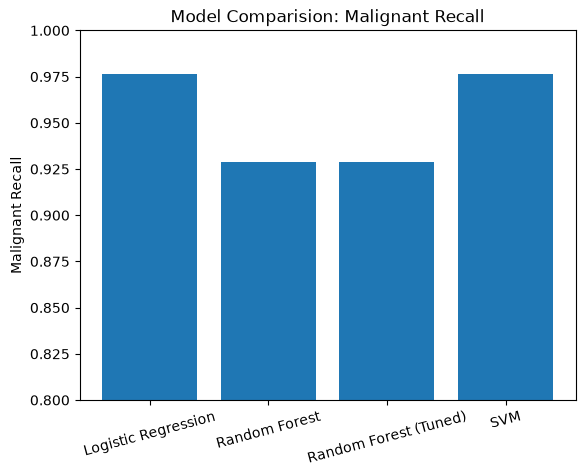

In [43]:
report_rf_tuned = classification_report(y_test, best_rf_pred, target_names=data.target_names, output_dict=True)

models = ['Logistic Regression', 'Random Forest', 'Random Forest (Tuned)', 'SVM']
recalls = [
    report_lr['malignant']['recall'],
    report_rf['malignant']['recall'],
    report_rf_tuned['malignant']['recall'],
    report_svm['malignant']['recall']
]

plt.bar(models, recalls)
plt.ylabel('Malignant Recall')
plt.title('Model Comparision: Malignant Recall')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)
plt.savefig('../results/model_comparison.png')
plt.show()